In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import numpy as np

In [ ]:
seed = 42
max_iteration = 1000
results_path = Path.cwd().parent / "model_output" / "MinvA" / f"results_MInvA_seed_{seed}_max_i{max_iteration}.json"
tmp_path = results_path.with_suffix(".tmp")

# Load existing data (if any)
if os.path.exists(results_path):
    print(f"Existing results found at {results_path}. Loading data...")
    with open(results_path, "r") as f:
        data = json.load(f)

df = pd.DataFrame(data)


Existing results found at d:\MasterThesis\project\Peeking-inside-the-Grid\training\model_output\smart_grid_anomaly\results_MInvA_seed_42_max_i1000_shuffle_false_full.json. Loading data...


In [ ]:
import pandas as pd

group_order = [
    "results_white",
    "results_grey",
    "results_black",
    "results_minus",
    "results_average",
    "results_average_class",
    "results_random",
    "results_from_test",
]

rows = []
for item in data:
    init_group = item.get("init_group")
    if init_group not in group_order:
        continue

    attack = item.get("attack", {})
    d0 = attack.get("distances_0") or attack.get("distances0")
    d1 = attack.get("distances_1") or attack.get("distances1")
    idx0 = attack.get("indices_0") or attack.get("indices0")
    idx1 = attack.get("indices_1") or attack.get("indices1")
    if not d0:
        continue

    run = item.get("run")
    if run not in ["plain", "SHAP"]:
        continue

    closest_idx_0 = idx0[0] if idx0 else None
    closest_idx_1 = idx1[0] if idx1 else None

    label_0 = y_train[closest_idx_0] if closest_idx_0 is not None else None
    label_1 = y_train[closest_idx_1] if closest_idx_1 is not None else None

    correct_0 = (label_0 == 0) if label_0 is not None else None
    correct_1 = (label_1 == 1) if label_1 is not None else None

    row = {
        "init_group": init_group,
        "init_index": item.get("init_index"),
        "run": run,
    }

    if run == "plain":
        row["plain"] = d0[0]
        row["plain_closest_idx_0"] = closest_idx_0
        row["plain_label_0"] = label_0
        row["plain_correct_0"] = correct_0
        row["plain_closest_idx_1"] = closest_idx_1
        row["plain_label_1"] = label_1
        row["plain_correct_1"] = correct_1
    else:
        meta = item.get("meta", {}) or {}
        bs = meta.get("background_size")
        nex = meta.get("n_explanation")
        suffix = f"bs_{bs}_nex_{nex}"
        row[f"SHAP_{suffix}"] = d0[0]
        row[f"SHAP_{suffix}_closest_idx_0"] = closest_idx_0
        row[f"SHAP_{suffix}_label_0"] = label_0
        row[f"SHAP_{suffix}_correct_0"] = correct_0
        row[f"SHAP_{suffix}_closest_idx_1"] = closest_idx_1
        row[f"SHAP_{suffix}_label_1"] = label_1
        row[f"SHAP_{suffix}_correct_1"] = correct_1

    rows.append(row)

df = pd.DataFrame(rows)

result = (
    df.groupby(["init_group", "init_index", "run"], as_index=False)
      .first()
)

result["init_group"] = pd.Categorical(
    result["init_group"], categories=group_order, ordered=True
)
result = result.sort_values(["init_group", "init_index", "run"]).reset_index(drop=True)

correct_0_cols = [c for c in result.columns if c.endswith("_correct_0")]
correct_1_cols = [c for c in result.columns if c.endswith("_correct_1")]

summary_rows = []
for col in correct_0_cols + correct_1_cols:
    target_class = 0 if col.endswith("_correct_0") else 1
    variant = col.rsplit("_correct_", 1)[0]  # e.g. "plain" or "SHAP_bs_50_nex_10"
    n_total = result[col].notna().sum()
    n_correct = result[col].sum(skipna=True)
    summary_rows.append({
        "variant": variant,
        "target_class": target_class,
        "n_total": n_total,
        "n_correct": int(n_correct) if n_total else 0,
        "accuracy": (n_correct / n_total) if n_total else float("nan"),
    })

summary = pd.DataFrame(summary_rows).sort_values(["variant", "target_class"]).reset_index(drop=True)

print(result.to_string(index=False))
print()
print(summary.to_string(index=False))


In [ ]:
group_order = [
    "results_white",
    "results_grey",
    "results_black",
    "results_minus",
    "results_average",
    "results_average_class",
    "results_random",
    "results_from_test",
]

rows = []
for item in data:
    init_group = item.get("init_group")
    if init_group not in group_order:
        continue

    attack = item.get("attack", {})
    d0 = attack.get("distances_0") or attack.get("distances0")
    if not d0:
        continue

    run = item.get("run")
    if run not in ["plain", "SHAP"]:
        continue

    row = {
        "init_group": init_group,
        "init_index": item.get("init_index"),
    }

    if run == "plain":
        row["plain"] = d0[0]
    else:
        meta = item.get("meta", {}) or {}
        bs = meta.get("background_size")
        nex = meta.get("n_explanation")
        suffix = f"bs_{bs}_nex_{nex}"
        row[f"SHAP_{suffix}"] = d0[0]

    rows.append(row)

    rows.append({
        "init_group": init_group,
        "init_index": item.get("init_index"),
        "run": run,
        "distance": d0[0],
    })

df_output = pd.DataFrame(rows)

df = pd.DataFrame(rows)

result = (
    df.groupby(["init_group", "init_index"], as_index=False)
      .first()
)

shap_cols = sorted([c for c in result.columns if c.startswith("SHAP_bs_")])
for shap_col in shap_cols:
    suffix = shap_col[len("SHAP_"):]
    result[f"delta_{suffix}"] = result[shap_col] - result["plain"]

result["init_group"] = pd.Categorical(
    result["init_group"],
    categories=group_order,
    ordered=True,
)

ordered_cols = ["init_group", "init_index", "plain"]
for shap_col in shap_cols:
    suffix = shap_col[len("SHAP_"):]
    ordered_cols.extend([shap_col, f"delta_{suffix}"])

result = result[ordered_cols].sort_values(["init_group", "init_index"]).reset_index(drop=True)

print(result.to_string(index=False))

           init_group  init_index    plain  SHAP_bs_1000_nex_100  delta_bs_1000_nex_100  SHAP_bs_1000_nex_1000  delta_bs_1000_nex_1000  SHAP_bs_1000_nex_200  delta_bs_1000_nex_200  SHAP_bs_1000_nex_500  delta_bs_1000_nex_500
        results_white           0 4.829579              4.819746              -0.009833               4.827687               -0.001892              4.825286              -0.004293              4.828890              -0.000690
         results_grey           0 5.920508              4.881831              -1.038677               4.902344               -1.018164              4.889532              -1.030976              4.902406              -1.018102
        results_black           0 7.385194              6.617673              -0.767521               6.627741               -0.757454              6.620726              -0.764468              6.629264              -0.755930
        results_minus           0 7.204157              6.736206              -0.467951             

In [4]:
print(f"Total samples: {len(result)}")
print(f"Groups: {result['init_group'].nunique()}")
print(f"SHAP configs: {len(shap_cols)}")

Total samples: 206
Groups: 8
SHAP configs: 4


plain                    7.165208
SHAP_bs_1000_nex_100     6.419601
SHAP_bs_1000_nex_1000    6.436115
SHAP_bs_1000_nex_200     6.420985
SHAP_bs_1000_nex_500     6.447347
dtype: float64


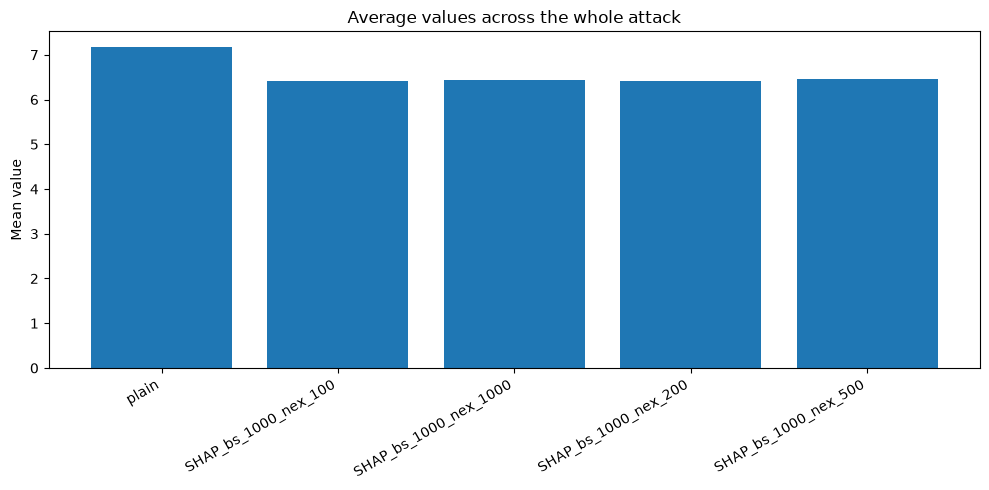

In [5]:
import pandas as pd



cols = [
    "plain",
    "SHAP_bs_1000_nex_100",
    "SHAP_bs_1000_nex_1000",
    "SHAP_bs_1000_nex_200",
    "SHAP_bs_1000_nex_500",
]

# average across the whole dataset for each column
overall_means = result[cols].mean()

print(overall_means)

plt.figure(figsize=(10, 5))
plt.bar(overall_means.index, overall_means.values)
plt.title("Average values across the whole attack")
plt.ylabel("Mean value")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

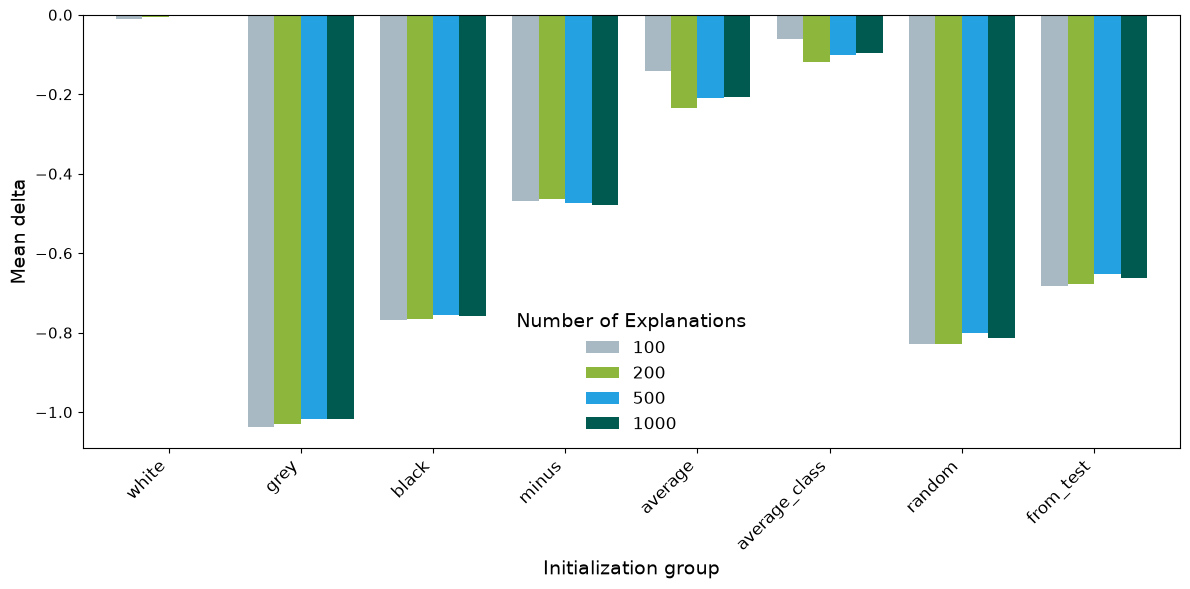

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

df = result.copy()

# Select delta columns
delta_cols = [
    c for c in df.columns
    if c.startswith("delta_")
]

# Optional: control the order of the attacks
delta_cols = [
    "delta_bs_1000_nex_100",
    "delta_bs_1000_nex_200",
    "delta_bs_1000_nex_500",
    "delta_bs_1000_nex_1000"
]


# Rename delta columns for display
attack_names = {
    "delta_bs_1000_nex_100": "100",
    "delta_bs_1000_nex_200": "200",
    "delta_bs_1000_nex_500": "500",
    "delta_bs_1000_nex_1000": "1000"
}


# Custom colors for the attacks
attack_colors = {
    "100": "#A8B9C4",
    "200": "#8CB63C",
    "500": "#23A1E0",
    "1000": "#005A50"
}

# Aggregate
grouped = (
    df.groupby("init_group")[delta_cols]
      .mean()
      .rename(columns=attack_names)
      .rename(index=lambda x: str(x).removeprefix("results_"))
)

# Plot
ax = grouped.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=[
        attack_colors[name]
        for name in grouped.columns
    ]
)

"""
# Titles and labels
ax.set_title(
    "Mean delta values compared to plain Model Iversion attack grouped by initialization group and attack",
    fontsize=16,
    fontweight="bold"
)
"""

ax.set_ylabel("Mean delta", fontsize=14)
ax.set_xlabel("Initialization group", fontsize=14)

# Change legend title from Method to Attack
ax.legend(
    title="Number of Explanations",
    title_fontsize=14,
    fontsize=12,
    frameon=False
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=12
)

plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

dataset_rs = 42
max_iteration = 10000
# seed important for x_init generation
seed=42
np.random.seed(seed)

# For downloading dataset
dst_path = Path.cwd() / "input" / "smart-grid-real-time-load-monitoring-dataset"

if not (dst_path / "smart_grid_dataset.csv").exists():

    # Download latest version
    src_path = Path(kagglehub.dataset_download("ziya07/smart-grid-real-time-load-monitoring-dataset"))
    
    # Destination: current working directory
    
    
    dst_path.mkdir(parents=True, exist_ok=True)
    
    # Copy all files
    for item in src_path.iterdir():
        if item.is_file():
            shutil.copy(item, dst_path / item.name)
    
    print("Dataset copied to:", dst_path)

# Load data
print("Loading file...")
try:
    df_base =pd.read_csv('input/smart-grid-real-time-load-monitoring-dataset/smart_grid_dataset.csv',delimiter=',')
    print(f"✓ Loaded {len(df_base):,} total rows")
except FileNotFoundError as e:
    print(f"✗ Error: File '{e.filename}' not found!")
except Exception as e:
    print(f"✗ Error loading file: {e}")

# Convert to proper pandas datetime objects
df_base['Timestamp'] = pd.to_datetime(df_base['Timestamp'])


# Create a copy for processing to keep the original df_base intact
df_processed = df_base.copy()
# sort the dataset by timestamp
df_processed = df_processed.sort_values(by="Timestamp", ascending=True).reset_index(drop=True)

df_processed.ffill(inplace=True)
df_processed.bfill(inplace=True)

# Creating combined Anomaly Label
print("Creating combined Anomaly Label...")

if 'Overload Condition' in df_processed.columns and 'Transformer Fault' in df_processed.columns:
    df_processed['Combined_Anomaly'] = ((df_processed['Overload Condition'] == 1) | (df_processed['Transformer Fault'] == 1)).astype(int)
    print("✓ 'Combined_Anomaly' column created.")
else:
    print("✗ Warning: 'Overload Condition' or 'Transformer Fault' column not found. Skipping 'Combined_Anomaly' creation.")
    df_processed['Combined_Anomaly'] = 0
    print("A dummy 'Combined_Anomaly' column (all zeros) has been created. Anomaly detection will not be meaningful without true labels.")

print("\nDistribution of Combined_Anomaly:")
initial_anomaly_counts = df_processed['Combined_Anomaly'].value_counts()
print(initial_anomaly_counts)

print("✓ Combined Anomaly Label creation complete.")


df_cor = df_processed.drop(['Transformer Fault', 'Overload Condition'], axis=1)
df_cor['Hour'] = df_processed['Timestamp'].dt.hour
df_cor['Dayofweek'] = df_processed['Timestamp'].dt.dayofweek
df_cor['month'] = df_processed['Timestamp'].dt.month

print("Scaling Data...")

y_true_full = df_processed['Combined_Anomaly']

columns_to_exclude = [
    'Overload Condition', 'Transformer Fault', 'Combined_Anomaly',
    'Timestamp', 'Predicted Load (kW)'
]
X_cols = [col for col in df_processed.columns if col not in columns_to_exclude]
X = df_processed[X_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"Features (X_scaled_df) shape after scaling: {X_scaled_df.shape}")
print(f"Labels (y_true_full) shape: {y_true_full.shape}")
print("✓ Data scaling complete.")


timestamp_s = pd.to_datetime(df_processed['Timestamp']).map(pd.Timestamp.timestamp)
hour = 60*60
day = 24*60*60
year = (365.2425)*day
X_scaled_df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
X_scaled_df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
X_scaled_df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
X_scaled_df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
print("✓ Added sine/cosine timestamp data as features")

'''
# Adding Timestamp data back in after scaling
X_scaled_df['Hour'] = df_processed['Timestamp'].dt.hour
X_scaled_df['Dayofweek'] = df_processed['Timestamp'].dt.dayofweek
X_scaled_df['month'] = df_processed['Timestamp'].dt.month
print("✓ Added timestamp data as features")
'''

print("\nFirst 5 rows of scaled features:")
print(X_scaled_df.head())
print("\nFirst 5 rows of target:")
print(y_true_full.head())

print(f"Features (X_scaled_df) shape after adding time: {X_scaled_df.shape}")


print("Feature Engineering...")

sequence_length = 4
print(f" Sequence Length is {sequence_length}")

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])  # Past 4 timesteps
        ys.append(y[i])            # Target: next timestep label
    return np.array(Xs), np.array(ys)


X_seq, y_seq = create_sequences(X_scaled_df.to_numpy(), y_true_full.to_numpy(), sequence_length)
print(f"One Data contains of {sequence_length} timestamps") 

# One-hot encoding
#y_seq = ku.to_categorical(y_seq, num_classes=2)


min_array = np.min(X_seq, axis=(0,1))
max_array = np.max(X_seq, axis=(0,1))

clip_min = min_array
clip_max = max_array

#clip_min = np.tile(min_array, (4, 1))[:, :, np.newaxis]
#clip_max = np.tile(max_array, (4, 1))[:, :, np.newaxis]

X_train, X_t, y_train, y_t = train_test_split(X_seq, y_seq, test_size=0.40, random_state=dataset_rs, shuffle=False)
X_test, X_val, y_test, y_val = train_test_split(X_t, y_t, test_size=0.50, random_state=dataset_rs, shuffle=False)
print("Split complete.")

Loading file...
✓ Loaded 50,000 total rows
Creating combined Anomaly Label...
✓ 'Combined_Anomaly' column created.

Distribution of Combined_Anomaly:
Combined_Anomaly
0    43721
1     6279
Name: count, dtype: int64
✓ Combined Anomaly Label creation complete.
Scaling Data...
Features (X_scaled_df) shape after scaling: (50000, 12)
Labels (y_true_full) shape: (50000,)
✓ Data scaling complete.
✓ Added sine/cosine timestamp data as features

First 5 rows of scaled features:
   Voltage (V)  Current (A)  Power Consumption (kW)  Reactive Power (kVAR)  \
0     0.497056    -1.721938               -1.715484              -1.228261   
1    -0.137821    -0.405810               -0.410379              -0.348346   
2     0.648006     1.436332                1.484581               1.250252   
3     1.523207     1.553148                1.672641               0.386404   
4    -0.233695    -1.545917               -1.546838              -0.994354   

   Power Factor  Solar Power (kW)  Wind Power (kW)  Grid 

In [8]:
import pandas as pd

group_order = [
    "results_white",
    "results_grey",
    "results_black",
    "results_minus",
    "results_average",
    "results_average_class",
    "results_random",
    # "results_random_clipped",
    "results_from_test",
]

rows = []
for item in data:
    init_group = item.get("init_group")
    if init_group not in group_order:
        continue

    attack = item.get("attack", {})
    d0 = attack.get("distances_0") or attack.get("distances0")
    d1 = attack.get("distances_1") or attack.get("distances1")
    idx0 = attack.get("indices_0") or attack.get("indices0")
    idx1 = attack.get("indices_1") or attack.get("indices1")
    if not d0:
        continue

    run = item.get("run")
    if run not in ["plain", "SHAP"]:
        continue

    closest_idx_0 = idx0[0] if idx0 else None
    closest_idx_1 = idx1[0] if idx1 else None

    label_0 = y_train[closest_idx_0] if closest_idx_0 is not None else None
    label_1 = y_train[closest_idx_1] if closest_idx_1 is not None else None

    correct_0 = (label_0 == 0) if label_0 is not None else None
    correct_1 = (label_1 == 1) if label_1 is not None else None

    row = {
        "init_group": init_group,
        "init_index": item.get("init_index"),
        "run": run,
    }

    if run == "plain":
        row["plain"] = d0[0]
        row["plain_closest_idx_0"] = closest_idx_0
        row["plain_label_0"] = label_0
        row["plain_correct_0"] = correct_0
        row["plain_closest_idx_1"] = closest_idx_1
        row["plain_label_1"] = label_1
        row["plain_correct_1"] = correct_1
    else:
        meta = item.get("meta", {}) or {}
        bs = meta.get("background_size")
        nex = meta.get("n_explanation")
        suffix = f"bs_{bs}_nex_{nex}"
        row[f"SHAP_{suffix}"] = d0[0]
        row[f"SHAP_{suffix}_closest_idx_0"] = closest_idx_0
        row[f"SHAP_{suffix}_label_0"] = label_0
        row[f"SHAP_{suffix}_correct_0"] = correct_0
        row[f"SHAP_{suffix}_closest_idx_1"] = closest_idx_1
        row[f"SHAP_{suffix}_label_1"] = label_1
        row[f"SHAP_{suffix}_correct_1"] = correct_1

    rows.append(row)

df = pd.DataFrame(rows)

result = (
    df.groupby(["init_group", "init_index", "run"], as_index=False)
      .first()
)

result["init_group"] = pd.Categorical(
    result["init_group"], categories=group_order, ordered=True
)
result = result.sort_values(["init_group", "init_index", "run"]).reset_index(drop=True)

correct_0_cols = [c for c in result.columns if c.endswith("_correct_0")]
correct_1_cols = [c for c in result.columns if c.endswith("_correct_1")]

summary_rows = []
for col in correct_0_cols + correct_1_cols:
    target_class = 0 if col.endswith("_correct_0") else 1
    variant = col.rsplit("_correct_", 1)[0]  # e.g. "plain" or "SHAP_bs_50_nex_10"
    n_total = result[col].notna().sum()
    n_correct = result[col].sum(skipna=True)
    summary_rows.append({
        "variant": variant,
        "target_class": target_class,
        "n_total": n_total,
        "n_correct": int(n_correct) if n_total else 0,
        "accuracy": (n_correct / n_total) if n_total else float("nan"),
    })

summary = pd.DataFrame(summary_rows).sort_values(["variant", "target_class"]).reset_index(drop=True)

print(result.to_string(index=False))
print()
print(summary.to_string(index=False))


           init_group  init_index   run    plain  plain_closest_idx_0  plain_label_0 plain_correct_0  plain_closest_idx_1  plain_label_1 plain_correct_1  SHAP_bs_1000_nex_100  SHAP_bs_1000_nex_100_closest_idx_0  SHAP_bs_1000_nex_100_label_0 SHAP_bs_1000_nex_100_correct_0  SHAP_bs_1000_nex_100_closest_idx_1  SHAP_bs_1000_nex_100_label_1 SHAP_bs_1000_nex_100_correct_1  SHAP_bs_1000_nex_200  SHAP_bs_1000_nex_200_closest_idx_0  SHAP_bs_1000_nex_200_label_0 SHAP_bs_1000_nex_200_correct_0  SHAP_bs_1000_nex_200_closest_idx_1  SHAP_bs_1000_nex_200_label_1 SHAP_bs_1000_nex_200_correct_1  SHAP_bs_1000_nex_500  SHAP_bs_1000_nex_500_closest_idx_0  SHAP_bs_1000_nex_500_label_0 SHAP_bs_1000_nex_500_correct_0  SHAP_bs_1000_nex_500_closest_idx_1  SHAP_bs_1000_nex_500_label_1 SHAP_bs_1000_nex_500_correct_1  SHAP_bs_1000_nex_1000  SHAP_bs_1000_nex_1000_closest_idx_0  SHAP_bs_1000_nex_1000_label_0 SHAP_bs_1000_nex_1000_correct_0  SHAP_bs_1000_nex_1000_closest_idx_1  SHAP_bs_1000_nex_1000_label_1 SHAP_bs_

In [36]:
# X_train contains the first training sequences
n_train_sequences = len(X_train)

# Each sequence starts at one raw row and contains sequence_length rows
n_train_rows = n_train_sequences + sequence_length

df_train_raw = df_processed.iloc[:n_train_rows].copy()

# Print the complete training-set Grid Supply column
print(
    df_train_raw[
        ["Timestamp", "Grid Supply (kW)"]
    ].to_string(index=False)
)

          Timestamp  Grid Supply (kW)
2024-01-01 00:00:00          0.000000
2024-01-01 00:15:00          0.000000
2024-01-01 00:30:00          0.000000
2024-01-01 00:45:00          0.000000
2024-01-01 01:00:00          0.000000
2024-01-01 01:15:00          0.000000
2024-01-01 01:30:00          0.000000
2024-01-01 01:45:00          0.000000
2024-01-01 02:00:00          0.000000
2024-01-01 02:15:00          0.000000
2024-01-01 02:30:00          0.000000
2024-01-01 02:45:00          0.000000
2024-01-01 03:00:00          0.000000
2024-01-01 03:15:00          0.000000
2024-01-01 03:30:00          0.000000
2024-01-01 03:45:00          0.000000
2024-01-01 04:00:00          0.000000
2024-01-01 04:15:00          0.000000
2024-01-01 04:30:00          0.000000
2024-01-01 04:45:00          0.000000
2024-01-01 05:00:00          2.627792
2024-01-01 05:15:00          0.000000
2024-01-01 05:30:00          0.000000
2024-01-01 05:45:00          0.000000
2024-01-01 06:00:00          0.000000
2024-01-01 0

In [8]:
print("Feature names in order:")
for i, col in enumerate(X_scaled_df.columns):
    print(f"{i}: {col}")

Feature names in order:
0: Voltage (V)
1: Current (A)
2: Power Consumption (kW)
3: Reactive Power (kVAR)
4: Power Factor
5: Solar Power (kW)
6: Wind Power (kW)
7: Grid Supply (kW)
8: Voltage Fluctuation (%)
9: Temperature (°C)
10: Humidity (%)
11: Electricity Price (USD/kWh)
12: Day sin
13: Day cos
14: Year sin
15: Year cos


In [ ]:
feature_names = [
    "Voltage (V)",
    "Current (A)",
    "Power Consumption (kW)",
    "Reactive Power (kVAR)",
    "Power Factor",
    "Solar Power (kW)",
    "Wind Power (kW)",
    "Grid Supply (kW)"
]

In [10]:
init_group_plot = "results_random"
init_index_plot = 9

In [21]:
def inverse_scale_sequence(sequence, scaler):
    """
    Inverse-transform the columns scaled by StandardScaler.
    Leave subsequently added cyclical features unchanged.
    """
    sequence = np.asarray(sequence, dtype=np.float64).copy()

    if sequence.ndim != 2:
        raise ValueError(
            f"Expected a 2D sequence with shape "
            f"(timesteps, features), got {sequence.shape}"
        )

    if sequence.shape[1] < scaler.n_features_in_:
        raise ValueError(
            f"Sequence has {sequence.shape[1]} features, but the scaler "
            f"expects {scaler.n_features_in_}."
        )

    # Inverse-transform only the originally scaled columns
    sequence[:, :scaler.n_features_in_] = scaler.inverse_transform(
        sequence[:, :scaler.n_features_in_]
    )
    
    # Any remaining columns, such as Day/Year sin/cos, remain unchanged
    return sequence


In [ ]:
feature_names_full = [
    "Voltage (V)",
    "Current (A)",
    "Power Consumption (kW)",
    "Reactive Power (kVAR)",
    "Power Factor",
    "Solar Power (kW)",
    "Wind Power (kW)",
    "Grid Supply (kW)",
    "Voltage Fluctuation (%)",
    "Temperature (°C)",
    "Humidity (%)",
    "Electricity Price (USD/kWh)",
    "Day sin",
    "Day cos",
    "Year sin",
    "Year cos"
]

Most similar training sample for inferred data point 0 from grey: 5470
Distance: 7.247159358274212
Sample no: 5470 was 0
shape sample (4, 16)
shape datapoint_grey_0 (4, 16)


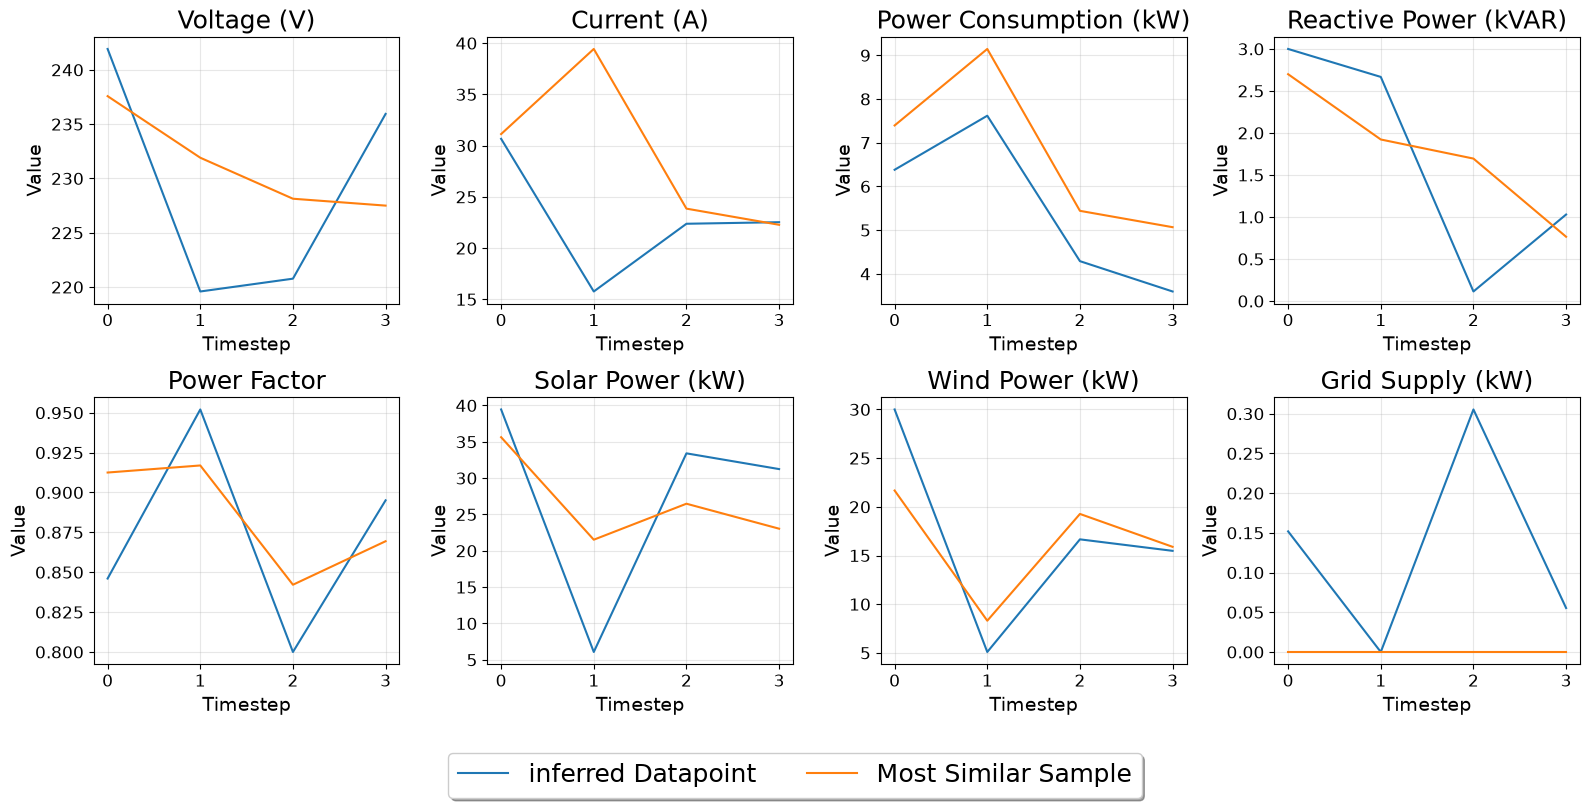

In [25]:
target_entry = None
for item in data:
    init_group = item.get("init_group")
    init_index = item.get("init_index")
    run = item.get("run")
    
    if init_group == init_group_plot and init_index == init_index_plot and run == "plain":
        target_entry = item
        break

if target_entry is None:
    raise ValueError("No matching entry found for results_grey, init_index=0, run='plain'")

# Extract distances_0 (or distances0)
attack = target_entry.get("attack", {})
distances_0 = attack.get("distances_0") or attack.get("distances0")
indices_0 = attack.get("indices_0") or attack.get("indices0")

if not distances_0 or not indices_0:
    raise ValueError("No distances_0/indices_0 or distances0/indices0 found in the attack field")

# Get the first distance and corresponding index
distance = distances_0[0]
index = indices_0[0]

print(f"Most similar training sample for inferred data point 0 from grey: {index}")
print(f"Distance: {distance}")

# Now use index to get the sample
sample = X_train[index]  # Replace with your actual sample variable
print(f"Sample no: {index} was {y_train[index]}")

# Extract the inferred datapoint (x_infer[0] from the attack object)
x_infer = attack.get("x_infer", [])
if x_infer:
    datapoint_grey_0 = np.array(x_infer[0])  # First inferred datapoint
else:
    raise ValueError("No x_infer found in the attack field")

print("shape sample", sample.shape)
print("shape datapoint_grey_0", datapoint_grey_0.shape)

# Convert both sequences back to original physical units
datapoint_grey_0_original = inverse_scale_sequence(
    datapoint_grey_0,
    scaler
)

sample_original = inverse_scale_sequence(
    sample,
    scaler
)

"""
# Original, unscaled physical features
X_original = df_processed[X_cols].to_numpy(dtype=np.float64)

# Number of features fitted by StandardScaler
n_scaled_features = scaler.n_features_in_

# Sequence length
seq_len = sample.shape[0]

# Reconstruct the corresponding raw sample
# X_seq[i] was created from raw rows i : i + seq_len
raw_sample = X_original[index:index + seq_len]

print("raw_sample:", raw_sample)
print("sample_original:", sample_original)
"""

# Create a figure with 8 subplots (2 rows x 4 columns for better layout)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Plot each feature across timesteps for both datapoint_0 and sample
for i in range(8):
    axes[i].plot(datapoint_grey_0_original[:, i], label='inferred Datapoint' if i == 0 else "")
    axes[i].plot(sample_original[:, i], label='Most Similar Sample' if i == 0 else "")
    axes[i].set_title(f'{feature_names[i]}', fontsize=18)
    axes[i].set_xlabel('Timestep', fontsize=14)
    axes[i].set_ylabel('Value', fontsize=14)
    axes[i].tick_params(labelsize=12)
    axes[i].grid(True, alpha=0.3)

# Single large legend below all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', 
           bbox_to_anchor=(0.5, -0.02), 
           ncol=2, fontsize=18, frameon=True, 
           framealpha=1.0, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # Make room for legend at bottom
plt.show()

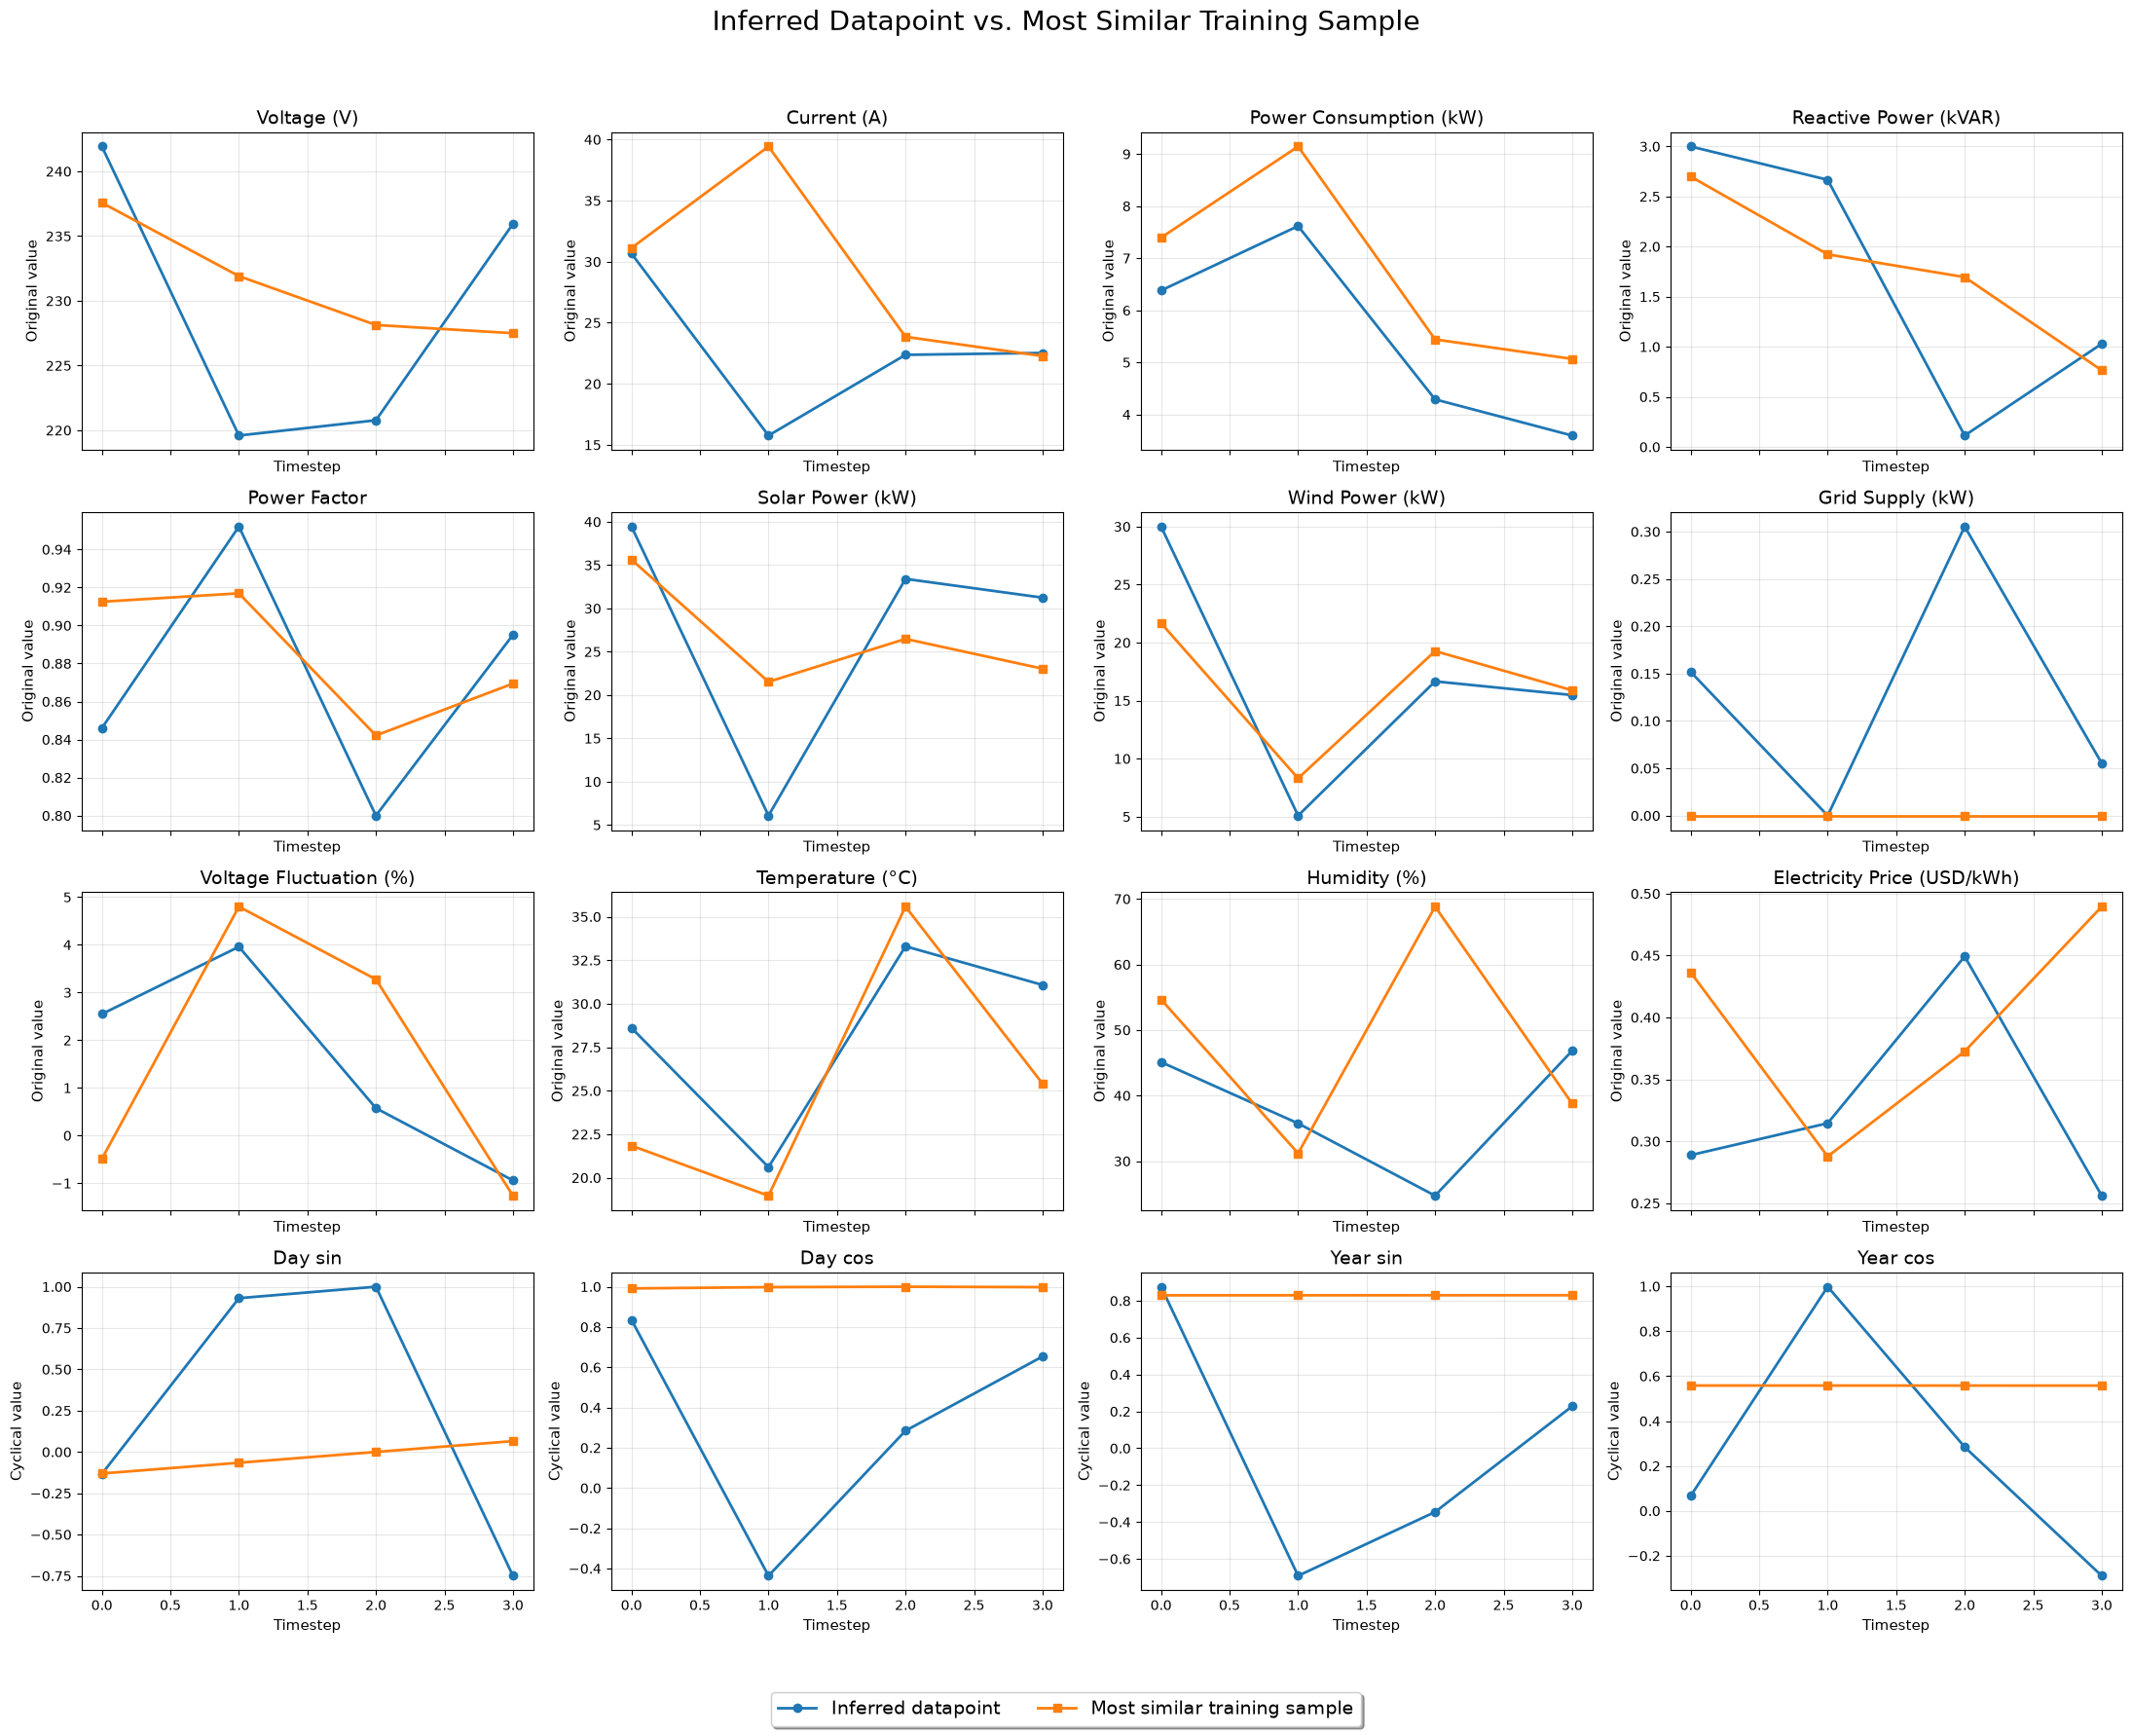

In [32]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(22, 18),
    sharex=True
)

axes = axes.flatten()

for i, feature_name in enumerate(feature_names):
    axes[i].plot(
        datapoint_grey_0_original[:, i],
        marker="o",
        linewidth=2,
        label="Inferred datapoint" if i == 0 else None
    )

    axes[i].plot(
        sample_original[:, i],
        marker="s",
        linewidth=2,
        label="Most similar training sample" if i == 0 else None
    )

    axes[i].set_title(feature_name, fontsize=14)
    axes[i].set_xlabel("Timestep", fontsize=11)

    if i < scaler.n_features_in_:
        axes[i].set_ylabel("Original value", fontsize=11)
    else:
        axes[i].set_ylabel("Cyclical value", fontsize=11)

    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis="both", labelsize=10)

# Obtain legend handles from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=14,
    frameon=True,
    framealpha=1.0,
    fancybox=True,
    shadow=True
)

fig.suptitle(
    "Inferred Datapoint vs. Most Similar Training Sample",
    fontsize=20,
    y=0.995
)

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

Most similar training sample for inferred data point 0 from grey: 13930
Distance: 5.877940119184013
Sample no: 13930 was 0


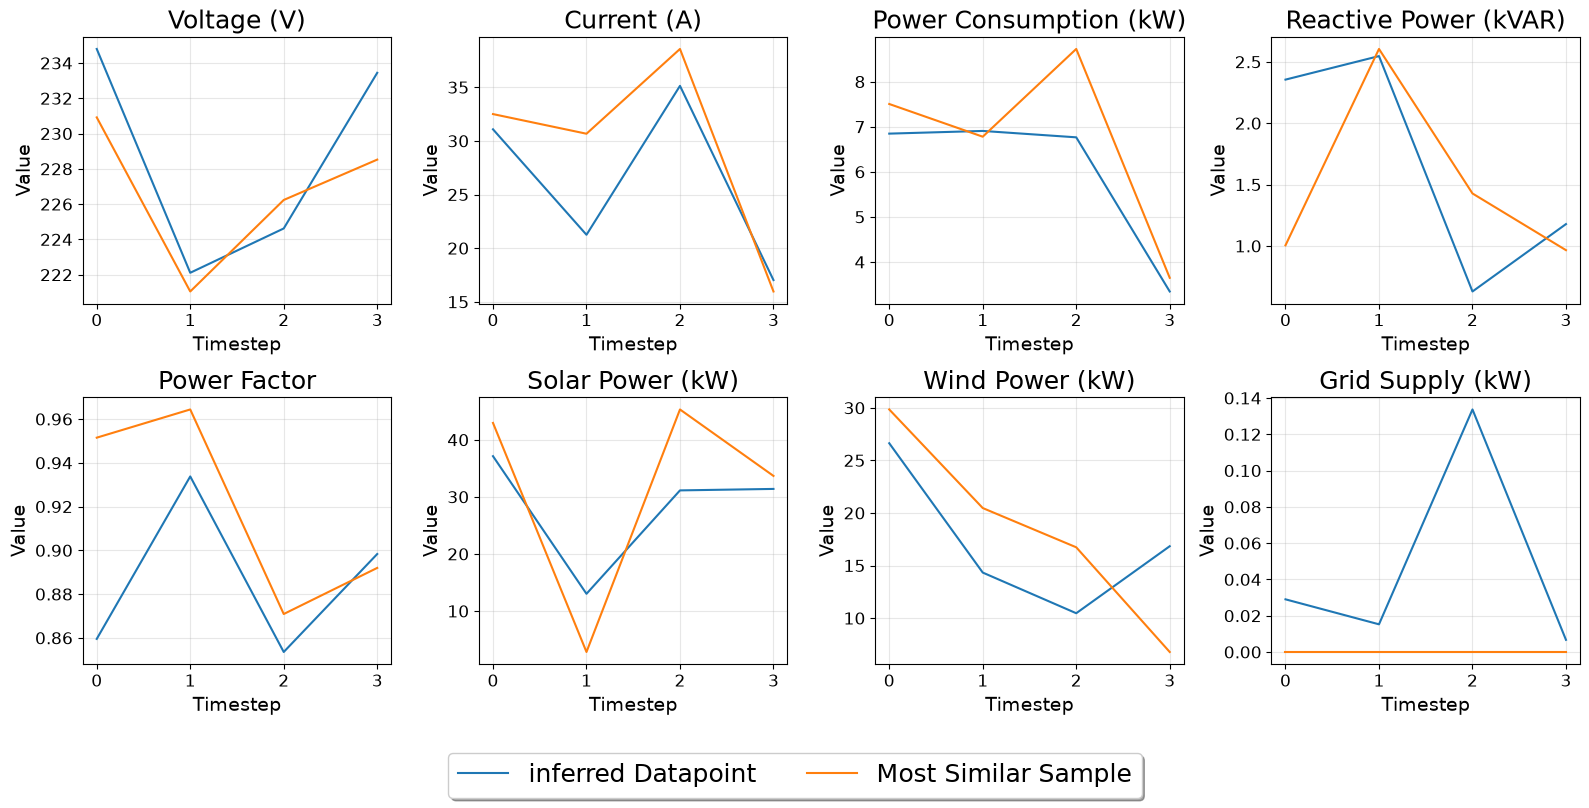

In [37]:
target_entry = None
for item in data:
    init_group = item.get("init_group")
    init_index = item.get("init_index")
    run = item.get("run")
    
    if init_group == init_group_plot and init_index == init_index_plot and run == "SHAP":
        meta = item.get("meta", {}) or {}
        bs = meta.get("background_size")
        nex = meta.get("n_explanation")
        
        if bs == 1000 and nex == 100:
            target_entry = item
            break

if target_entry is None:
    raise ValueError("No matching entry found for results_grey, init_index=0, run='SHAP', bs=1000, nex=100")

# Extract distances_0 (or distances0)
attack = target_entry.get("attack", {})
distances_0 = attack.get("distances_0") or attack.get("distances0")
indices_0 = attack.get("indices_0") or attack.get("indices0")

if not distances_0 or not indices_0:
    raise ValueError("No distances_0/indices_0 or distances0/indices0 found in the attack field")

# Get the first distance and corresponding index
distance = distances_0[0]
index = indices_0[0]

print(f"Most similar training sample for inferred data point 0 from grey: {index}")
print(f"Distance: {distance}")

# Now use index to get the sample
sample_SHAP = X_train[index]  # Replace with your actual sample variable
print(f"Sample no: {index} was {y_train[index]}")

# Extract the inferred datapoint (x_infer[0] from the attack object)
x_infer = attack.get("x_infer", [])
if x_infer:
    datapoint_grey_0_SHAP = np.array(x_infer[0])  # First inferred datapoint
else:
    raise ValueError("No x_infer found in the attack field")

# Convert both sequences back to original physical units
datapoint_grey_0_SHAP_original = inverse_scale_sequence(
    datapoint_grey_0_SHAP,
    scaler
)

sample_SHAP_original = inverse_scale_sequence(
    sample_SHAP,
    scaler
)

# Create a figure with 8 subplots (2 rows x 4 columns for better layout)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Plot each feature across timesteps for both datapoint_0 and sample
for i in range(8):
    axes[i].plot(datapoint_grey_0_SHAP_original[:, i], label='inferred Datapoint' if i == 0 else "")
    axes[i].plot(sample_SHAP_original[:, i], label='Most Similar Sample' if i == 0 else "")
    axes[i].set_title(f'{feature_names[i]}', fontsize=18)
    axes[i].set_xlabel('Timestep', fontsize=14)
    axes[i].set_ylabel('Value', fontsize=14)
    axes[i].tick_params(labelsize=12)
    axes[i].grid(True, alpha=0.3)

# Single large legend below all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', 
           bbox_to_anchor=(0.5, -0.02), 
           ncol=2, fontsize=18, frameon=True, 
           framealpha=1.0, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # Make room for legend at bottom
plt.show()